In [12]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# ==================== 1. 生成随机数据 ====================
np.random.seed(42)  # 固定随机种子
n = 500  # 样本数量
data = pd.DataFrame({
    "F2": np.random.normal(loc=50, scale=10, size=n),       # x 轴变量
    "target": np.random.normal(loc=100, scale=20, size=n)   # y 轴变量
})

# 输出前5行数据
print(data.head())

          F2      target
0  54.967142  118.523551
1  48.617357  138.188333
2  56.476885   72.028649
3  65.230299  111.259385
4  47.658466   86.987149


In [13]:
"""加载样式文件（如果存在），并设置中文字体支持"""
# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Helvetica", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

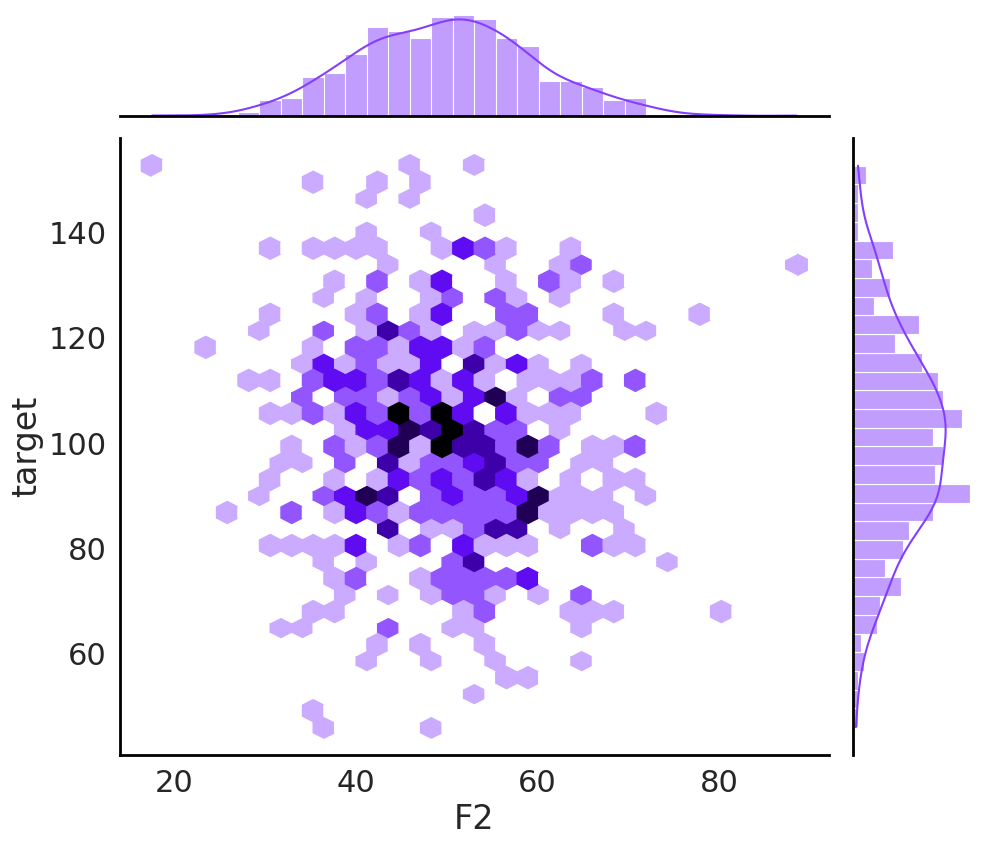

/home/bob/anaconda3/envs/boom/lib/python3.11/site-packages/seaborn/axisgrid.py:1832: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, y=self.y, **kwargs)
/home/bob/anaconda3/envs/boom/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


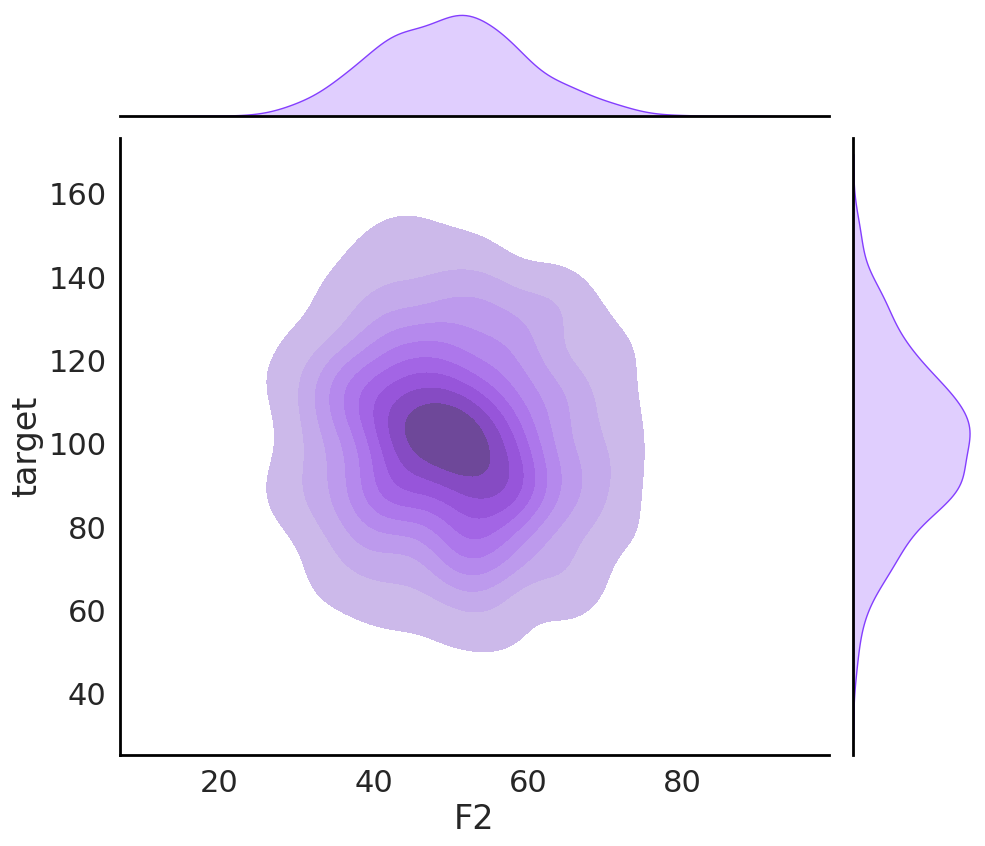

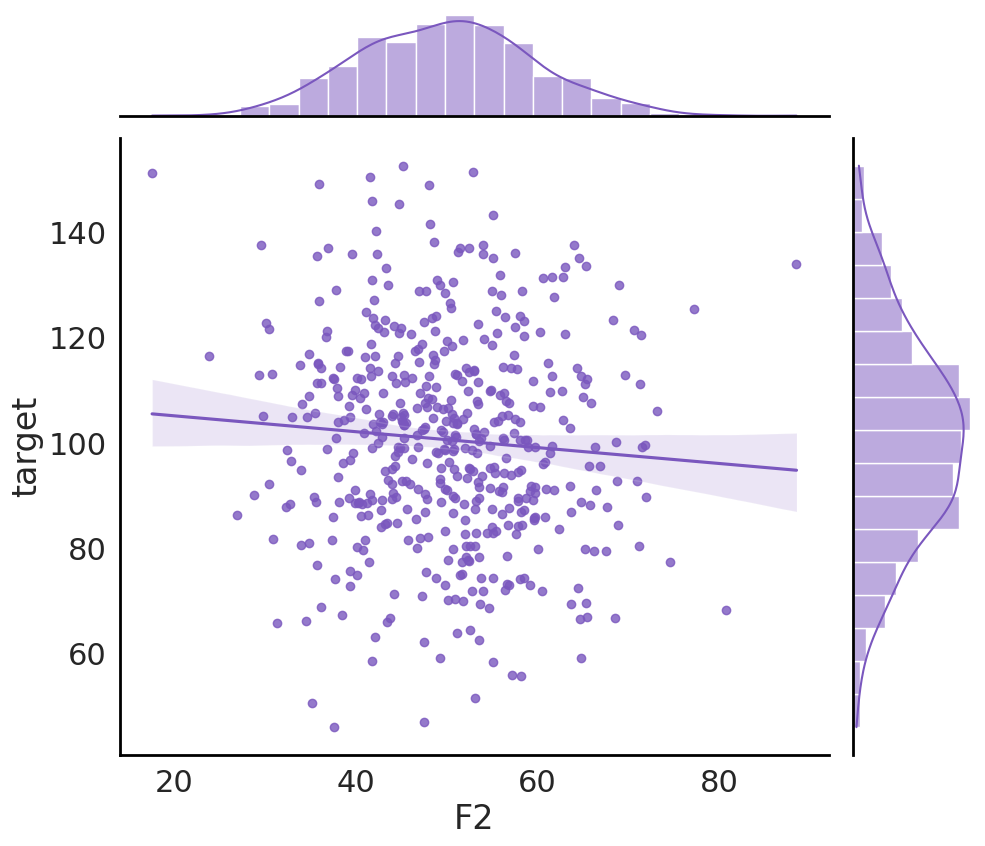

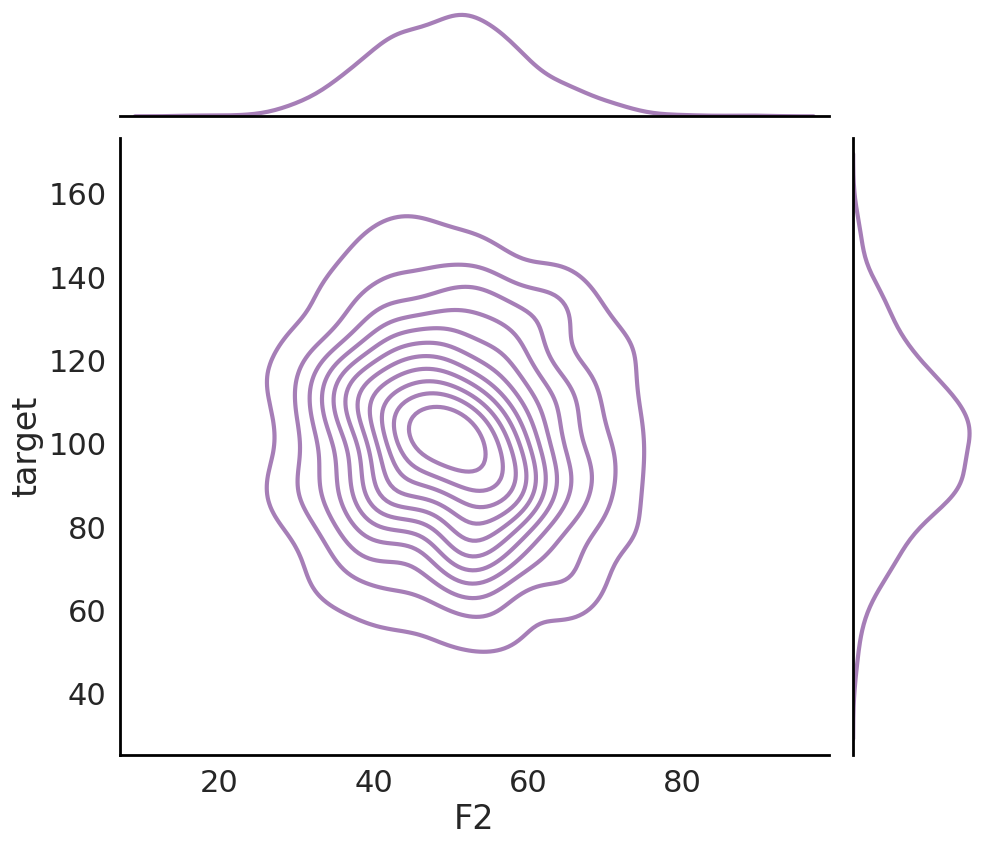

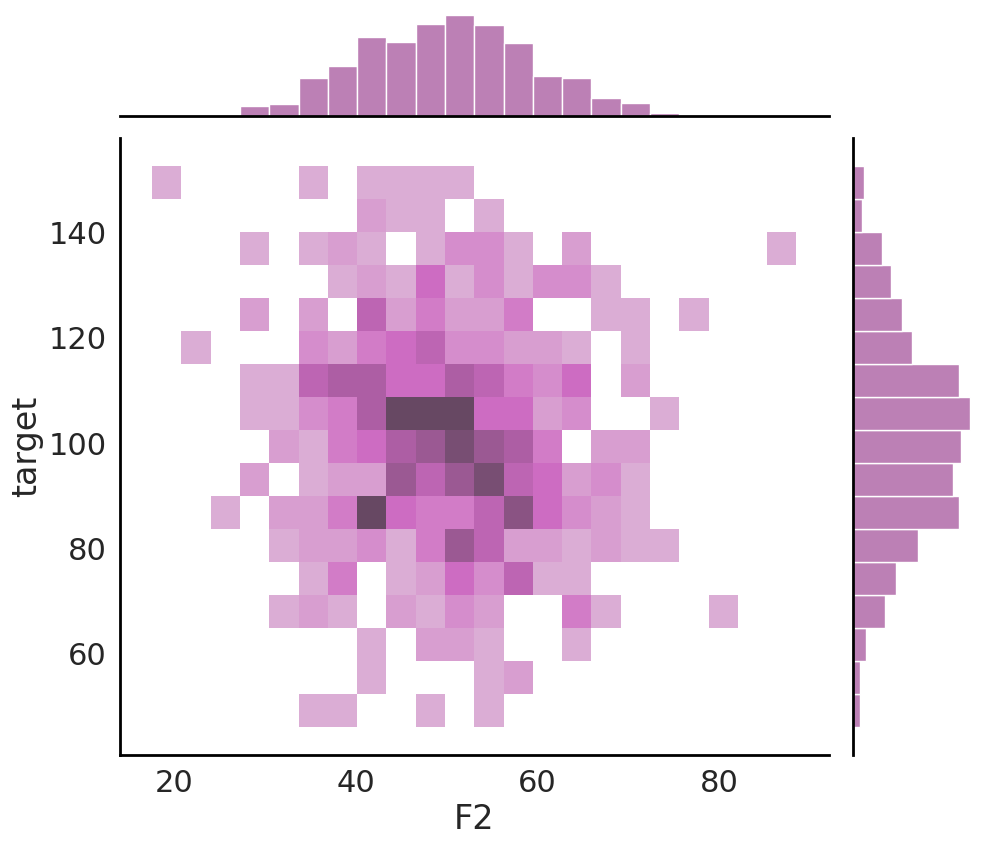

In [14]:
x = 'F2'
y = 'target'

# ==================== 2. 绘制多种联合分布图 ====================

# 1. 六边形分布 + 边际直方图 + KDE
sns.set(style="white", font_scale=2.0,
        rc={"axes.linewidth": 2, "axes.edgecolor": "black"},
         )
g = sns.jointplot(x=x, y=y,
                  data=data,
                  color='#843efe',
                  marginal_kws=dict(bins=30, kde=True, color='#843efe'),
                  kind='hex',
                  joint_kws={'gridsize': 30})
g.fig.set_size_inches(12, 10)
plt.show()

# 2. KDE 联合分布
sns.set(style="white", font_scale=2.0,
        rc={"axes.linewidth": 2, "axes.edgecolor": "black"},
         )
g = sns.jointplot(x=x, y=y,
                  data=data, color='#8835cf',
                  kind='kde',
                  marginal_kws=dict(fill=True, color='#843efe'),
                  joint_kws={'shade': True, 'linewidths': 0.5})
g.fig.set_size_inches(12, 10)
plt.show()

# 3. 带回归线的散点图
sns.set(style="white", font_scale=2.0,
        rc={"axes.linewidth": 2, "axes.edgecolor": "black"},
         )
g = sns.jointplot(x=x, y=y,
                  data=data, color='#7a57be',
                  kind='reg')
g.fig.set_size_inches(12, 10)
plt.show()

# 4. 等高线 KDE 联合分布
sns.set(style="white", font_scale=2.0,
        rc={"axes.linewidth": 2, "axes.edgecolor": "black"},
         )
g = sns.jointplot(x=x, y=y,
                  data=data, color='#a67eb7',
                  kind='kde',
                  levels=12,
                  linewidths=3)
# 调整边际 KDE 线条宽度
g.ax_marg_x.lines[0].set_linewidth(3)
g.ax_marg_y.lines[0].set_linewidth(3)
g.fig.set_size_inches(12, 10)
plt.show()

# 5. 直方图联合分布
sns.set(style="white", font_scale=2.0,
        rc={"axes.linewidth": 2, "axes.edgecolor": "black"},
         )
g = sns.jointplot(x=x, y=y,
                  data=data, color='#a6569d',
                  kind='hist')
g.fig.set_size_inches(12, 10)
plt.savefig('./Fig.pdf', dpi=300, bbox_inches='tight')
plt.show()
